# BCS 3101: Basics of Machine Learning
## Assignment 2 – Notebook 4

**Student Name:** NIYONSHUTI MERCY  
**Registration Number:** 2025/A/KCS/6117/F  
**Group Project:** Predicting Monthly Maize and Beans Prices in Selected Ugandan Markets  

This notebook continues **Stage 8: Data Pre-processing III – Data Transformation**.  
Notebook 3 already did the encoding of categorical variables.  
Here we focus on **feature scaling** (Min-Max normalisation and Z-score standardisation) and a short note on log transforms.

---
## Load the encoded data from Notebook 3

We load the file that already has one-hot encoded market columns and only numeric features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

%matplotlib inline
sns.set_style('whitegrid')

# Load the encoded dataset
df = pd.read_csv('uganda_maize_beans_encoded.csv')

print("Encoded data loaded.")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nColumn names:")
print(df.columns.tolist())

Encoded data loaded.
Rows: 1652, Columns: 22

Column names:
['year', 'month', 'lat', 'lon', 'c_maize', 'c_beans', 'c_oil', 'c_salt', 'c_food_price_index', 'inflation_maize', 'inflation_beans', 'trust_maize', 'trust_beans', 'data_coverage', 'data_coverage_recent', 'index_confidence_score', 'mkt_name_Gulu', 'mkt_name_Hoima', 'mkt_name_Jinja', 'mkt_name_Lira', 'mkt_name_Market Average', 'mkt_name_Mbarara']


---
## 8.2 Feature Scaling: Normalisation and Standardisation

> “Many algorithms, including anything based on distance (KNN, K-Means, SVM) or gradient descent (logistic regression, neural networks), are sensitive to the scale of each feature. A feature ranging from 0 to 1,000,000 will dominate a feature ranging from 0 to 1 purely because of its scale, not because it is more informative.”

Scaling puts every feature on a comparable footing.

### Two common methods

**Min-Max Normalisation**  
Rescales every value into a fixed range, usually [0, 1]:

X' = (X − Xmin) / (Xmax − Xmin)

Best when you know the approximate bounds of the data and want a bounded range.  
It is sensitive to outliers – one extreme value can stretch the whole range.

**Z-score Standardisation**  
Rescales every value so that it has a mean of 0 and a standard deviation of 1:

X' = (X − μ) / σ

Does not force values into a fixed range, but is more robust to outliers than Min-Max.  
It is the conventional choice for algorithms that assume roughly normally distributed, zero-centred input (for example PCA, logistic regression, SVM).

In [2]:
# Look at the current scale of the main numeric columns
numeric_cols = ['c_maize', 'c_beans', 'c_oil', 'c_salt', 'c_food_price_index',
                'year', 'month', 'lat', 'lon',
                'inflation_maize', 'inflation_beans',
                'trust_maize', 'trust_beans',
                'data_coverage', 'data_coverage_recent', 'index_confidence_score']

# Keep only columns that actually exist
numeric_cols = [c for c in numeric_cols if c in df.columns]

print("Summary statistics before scaling:")
print(df[numeric_cols].describe().round(2))

Summary statistics before scaling:
       c_maize  c_beans     c_oil   c_salt  c_food_price_index     year  \
count  1652.00  1652.00   1652.00  1652.00             1652.00  1652.00   
mean   1078.34  2667.87   6103.85  1758.49                0.90  2016.34   
std     458.97  1074.23   1538.67   382.63                0.27     5.68   
min     407.41   902.66   3087.13   948.41                0.42  2007.00   
25%     729.53  1855.69   5000.00  1482.66                0.69  2011.00   
50%     980.66  2480.04   5961.24  1770.60                0.90  2016.00   
75%    1300.00  3350.00   7126.81  1974.68                1.07  2021.00   
max    2870.68  6557.42  11655.23  3146.09                1.58  2026.00   

         month      lat      lon  inflation_maize  inflation_beans  \
count  1652.00  1416.00  1416.00          1568.00          1568.00   
mean      6.43     1.12    32.42            11.80             9.24   
std       3.44     1.15     1.15            37.72            25.65   
min      

We can already see the problem the guide describes.  
`c_maize` and `c_beans` are measured in thousands of UGX, while `month` is only 1–12 and `lat`/`lon` are small numbers.  
Without scaling, any distance-based or gradient-based algorithm would be dominated by the price columns.

### Important rule: fit only on training data

> “If you fit a scaler (or any pre-processing step) on the FULL dataset before splitting into train/test, information from the test set leaks into how the training data is scaled. This produces an overly optimistic, dishonest estimate… Always split first, then fit pre-processing steps on the training partition only.”

In this notebook we demonstrate the scalers on the whole table so the numbers are easy to see.  
In Notebook 5 (Reduction & Splitting) we will apply the correct order: split first, then fit the scaler only on the training part.

In [3]:
# Separate the target columns from the feature columns
target_cols = ['c_maize', 'c_beans']
feature_cols = [c for c in numeric_cols if c not in target_cols]

print("Feature columns that will be scaled:")
print(feature_cols)
print("\nTarget columns (left unscaled for now):")
print(target_cols)

Feature columns that will be scaled:
['c_oil', 'c_salt', 'c_food_price_index', 'year', 'month', 'lat', 'lon', 'inflation_maize', 'inflation_beans', 'trust_maize', 'trust_beans', 'data_coverage', 'data_coverage_recent', 'index_confidence_score']

Target columns (left unscaled for now):
['c_maize', 'c_beans']


We normally scale only the **features**, not the targets.  
The targets stay in their original units (UGX) so that predictions remain easy to interpret.

In [4]:
# --- Min-Max Normalisation ---
minmax_scaler = MinMaxScaler()
df_minmax = df.copy()
df_minmax[feature_cols] = minmax_scaler.fit_transform(df[feature_cols])

print("After Min-Max scaling (features only):")
print(df_minmax[feature_cols].describe().round(3))

After Min-Max scaling (features only):
          c_oil    c_salt  c_food_price_index      year     month       lat  \
count  1652.000  1652.000            1652.000  1652.000  1652.000  1416.000   
mean      0.352     0.369               0.413     0.492     0.494     0.511   
std       0.180     0.174               0.229     0.299     0.313     0.341   
min       0.000     0.000               0.000     0.000     0.000     0.000   
25%       0.223     0.243               0.233     0.211     0.182     0.305   
50%       0.335     0.374               0.414     0.474     0.455     0.462   
75%       0.471     0.467               0.562     0.737     0.727     0.840   
max       1.000     1.000               1.000     1.000     1.000     1.000   

            lon  inflation_maize  inflation_beans  trust_maize  trust_beans  \
count  1416.000         1568.000         1568.000     1652.000     1652.000   
mean      0.514            0.277            0.318        0.532        0.537   
std       0.

Every feature now lies between 0 and 1.  
The shape of each distribution is unchanged; only the scale has been compressed.

In [5]:
# --- Z-score Standardisation ---
standard_scaler = StandardScaler()
df_standard = df.copy()
df_standard[feature_cols] = standard_scaler.fit_transform(df[feature_cols])

print("After Z-score standardisation (features only):")
print(df_standard[feature_cols].describe().round(3))

After Z-score standardisation (features only):
          c_oil    c_salt  c_food_price_index      year     month       lat  \
count  1652.000  1652.000            1652.000  1652.000  1652.000  1416.000   
mean      0.000     0.000               0.000     0.000    -0.000    -0.000   
std       1.000     1.000               1.000     1.000     1.000     1.000   
min      -1.961    -2.118              -1.804    -1.644    -1.580    -1.501   
25%      -0.718    -0.721              -0.787    -0.940    -0.998    -0.606   
50%      -0.093     0.032               0.004    -0.060    -0.126    -0.146   
75%       0.665     0.565               0.653     0.821     0.747     0.965   
max       3.609     3.628               2.565     1.701     1.619     1.434   

            lon  inflation_maize  inflation_beans  trust_maize  trust_beans  \
count  1416.000         1568.000         1568.000     1652.000     1652.000   
mean     -0.000           -0.000            0.000        0.000       -0.000   
std 

After standardisation each feature has a mean close to 0 and a standard deviation close to 1.  
Values can be negative or larger than 1; that is expected.

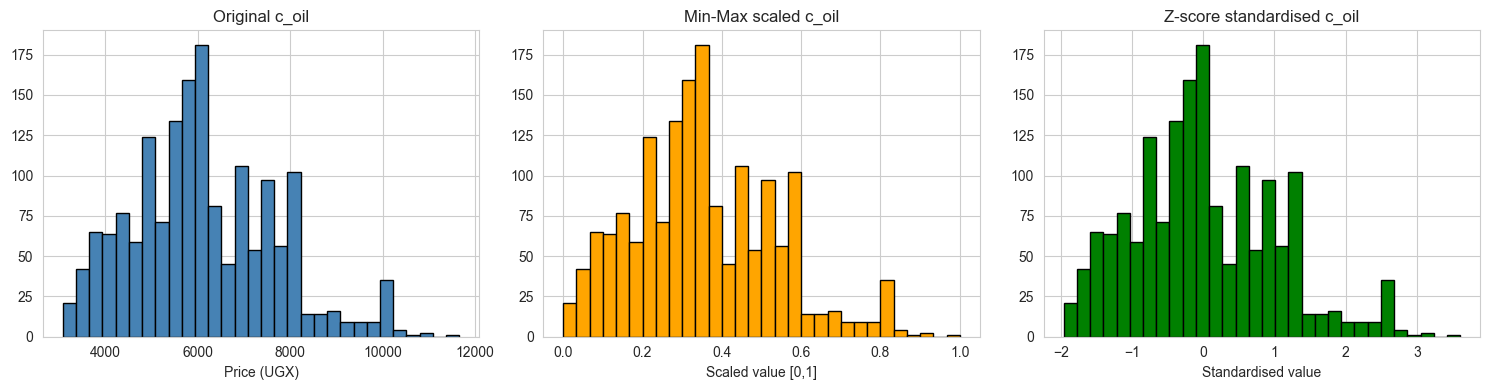

In [6]:
# Visual comparison of one feature before and after scaling
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['c_oil'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Original c_oil')
axes[0].set_xlabel('Price (UGX)')

axes[1].hist(df_minmax['c_oil'], bins=30, color='orange', edgecolor='black')
axes[1].set_title('Min-Max scaled c_oil')
axes[1].set_xlabel('Scaled value [0,1]')

axes[2].hist(df_standard['c_oil'], bins=30, color='green', edgecolor='black')
axes[2].set_title('Z-score standardised c_oil')
axes[2].set_xlabel('Standardised value')

plt.tight_layout()
plt.show()

The three histograms show the same shape.  
Only the horizontal scale changes. 

### Which scaler will we use?

We choose **Z-score standardization (StandardScaler)** for the rest of the pipeline.

**Reason:**  
Our price features contain genuine high values that the earlier outlier analysis decided to keep.  
Min-Max scaling is sensitive to those extremes: one very high price can squash most other values toward zero.  
Z-score standardisation is more robust to outliers and is the conventional choice when we later apply PCA or any algorithm that benefits from zero-centred features. 

### Log transform

> “When a numeric feature is heavily right-skewed … a log transform (log(x+1) …) compresses the tail and makes the distribution closer to symmetric/normal.”

Our target prices are right-skewed (common with prices).  
We show a log transform on the targets for illustration.  
Whether we finally model the log-price or the original price will be decided later.

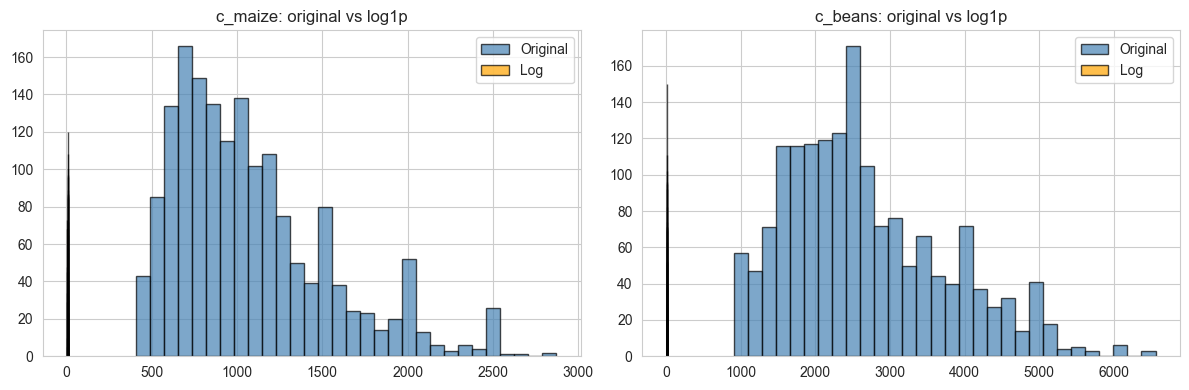

Skewness before log (c_maize): 1.11
Skewness after log  (c_maize): 0.25
Skewness before log (c_beans): 0.73
Skewness after log  (c_beans): -0.13


In [7]:
# Log transform of the two targets (illustration)
df['log_c_maize'] = np.log1p(df['c_maize'])   # log(1+x) is safe even if a zero appears
df['log_c_beans'] = np.log1p(df['c_beans'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['c_maize'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, label='Original')
axes[0].hist(df['log_c_maize'], bins=30, color='orange', edgecolor='black', alpha=0.7, label='Log')
axes[0].set_title('c_maize: original vs log1p')
axes[0].legend()

axes[1].hist(df['c_beans'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, label='Original')
axes[1].hist(df['log_c_beans'], bins=30, color='orange', edgecolor='black', alpha=0.7, label='Log')
axes[1].set_title('c_beans: original vs log1p')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Skewness before log (c_maize):", round(df['c_maize'].skew(), 2))
print("Skewness after log  (c_maize):", round(df['log_c_maize'].skew(), 2))
print("Skewness before log (c_beans):", round(df['c_beans'].skew(), 2))
print("Skewness after log  (c_beans):", round(df['log_c_beans'].skew(), 2))

The log transform reduces the right skew.  
We keep both the original and the log versions in the saved file so later notebooks can choose.

In [8]:
# Prepare the final table that will be used for splitting and modelling
# We keep the standardised features + original targets + log targets
df_scaled = df_standard.copy()
df_scaled['c_maize'] = df['c_maize']          # keep original target
df_scaled['c_beans'] = df['c_beans']
df_scaled['log_c_maize'] = df['log_c_maize']
df_scaled['log_c_beans'] = df['log_c_beans']

# Also keep the one-hot market columns (they are already 0/1, no need to scale)
market_cols = [c for c in df.columns if c.startswith('mkt_name_')]
for col in market_cols:
    if col in df.columns:
        df_scaled[col] = df[col]

print("Final columns in the scaled dataset:")
print(df_scaled.columns.tolist())
print(f"\nShape: {df_scaled.shape}")

# Save for Notebook 5
df_scaled.to_csv('uganda_maize_beans_scaled.csv', index=False)
print("\nScaled dataset saved as 'uganda_maize_beans_scaled.csv'")

Final columns in the scaled dataset:
['year', 'month', 'lat', 'lon', 'c_maize', 'c_beans', 'c_oil', 'c_salt', 'c_food_price_index', 'inflation_maize', 'inflation_beans', 'trust_maize', 'trust_beans', 'data_coverage', 'data_coverage_recent', 'index_confidence_score', 'mkt_name_Gulu', 'mkt_name_Hoima', 'mkt_name_Jinja', 'mkt_name_Lira', 'mkt_name_Market Average', 'mkt_name_Mbarara', 'log_c_maize', 'log_c_beans']

Shape: (1652, 24)

Scaled dataset saved as 'uganda_maize_beans_scaled.csv'


---
## Summary of scaling decisions

| Decision | Choice | Reason linked to our data |
|----------|--------|---------------------------|
| Scaler for features | StandardScaler (Z-score) | More robust to the genuine high prices we decided to keep; conventional for PCA and many models |
| Min-Max | Demonstrated but not chosen | Sensitive to outliers; would compress most values toward zero |
| Targets | Left in original UGX units | Predictions stay easy to interpret |
| Log transform | Applied to targets and saved | Reduces right skew; available if later modelling needs it |
| Fit on full data | Only for demonstration | Correct order (split → fit on train only) will be used in Notebook 5 |



### What we finished
- Loaded the encoded data from Notebook 3
- Showed the different scales of the features
- Applied both Min-Max and Z-score scaling
- Chose StandardScaler and justified the choice with our own outlier decision
- Demonstrated a log transform on the targets
- Saved a scaled dataset for the next notebook

### What comes next
Notebook 5 (ARINDA ELIZABETH) will handle **Stage 9: Reduction, Splitting and Model Readiness** – feature selection / PCA decision and the proper train-test split.